In [35]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.describe(include="all")

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
drop_cols = ["RowNumber", "CustomerId", "Surname"]
df = df.drop(columns=drop_cols)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Feature Engineering

In [12]:
df['AgeGroup'] = pd.qcut(df['Age'], q=6, labels=['Young', 'Adolescent', 'Adult', 'Middle-Aged', 'pre_Senior', 'Senior'])

In [20]:
df['Has_balance'] = df['Balance'].apply(lambda x: 1 if x > 0 else 0)

In [15]:
df['TenurePercentage'] = (df['Tenure'] / df['Age']) * 100

In [16]:
def extract_product_engagment(row):
    is_active, n_products = row['IsActiveMember'], row['NumOfProducts']

    if is_active == 0:
        return 'very_low_engagment'

    elif is_active == 1 and n_products == 1:
        return 'small_engagment'

    elif is_active == 1 and n_products == 2:
        return 'avg_engagment'

    elif is_active == 1 and n_products == 3:
        return 'above_avg_engagment'

    elif is_active == 1 and n_products == 4:
        return 'high_engagment'

df['products_engagment'] = df.apply(extract_product_engagment, axis=1)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,has_balance,TenurePercentage,products_engagment
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,pre_Senior,0,4.761905,small_engagment
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Middle-Aged,1,2.439024,small_engagment
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,pre_Senior,1,19.047619,very_low_engagment
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Middle-Aged,0,2.564103,very_low_engagment
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,pre_Senior,1,4.651163,small_engagment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,Middle-Aged,0,12.820513,very_low_engagment
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,Adult,1,28.571429,small_engagment
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,Adult,0,19.444444,small_engagment
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,pre_Senior,1,7.142857,very_low_engagment


# EDA

In [17]:
numerical_features = [
    "CreditScore", "Age", "Tenure", "Balance",
    "NumOfProducts", "EstimatedSalary","TenurePercentage"
]

binary_features = [
    "HasCrCard", "IsActiveMember","Has_balance"
]

categorical_features = [
    "Geography", "Gender","AgeGroup","products_engagment"
]

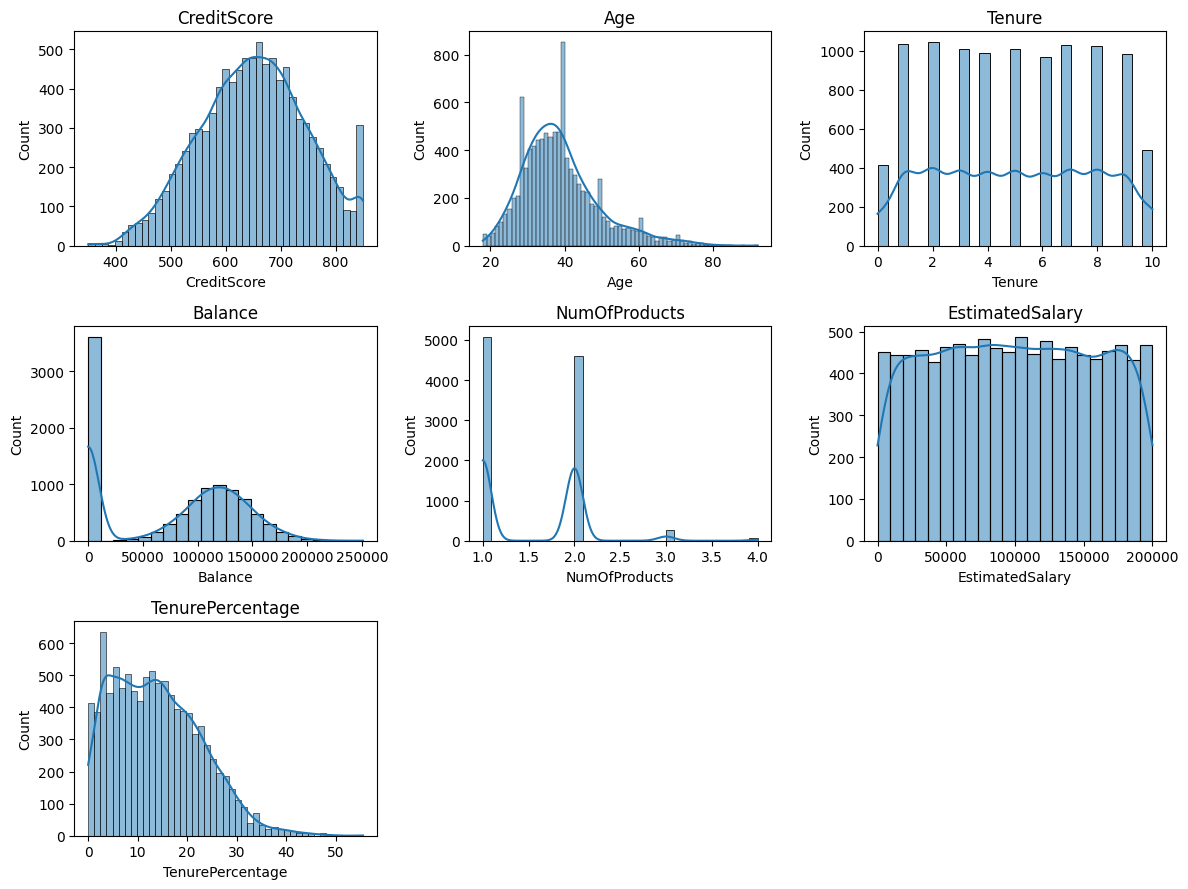

In [18]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n = len(numerical_features)
n_cols = math.ceil(math.sqrt(n))
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

# Hide unused axes
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

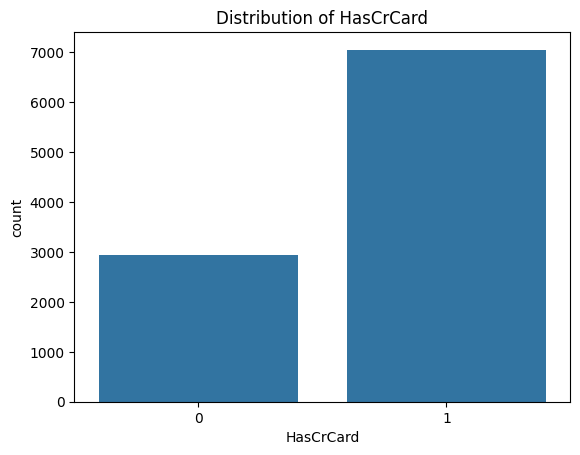

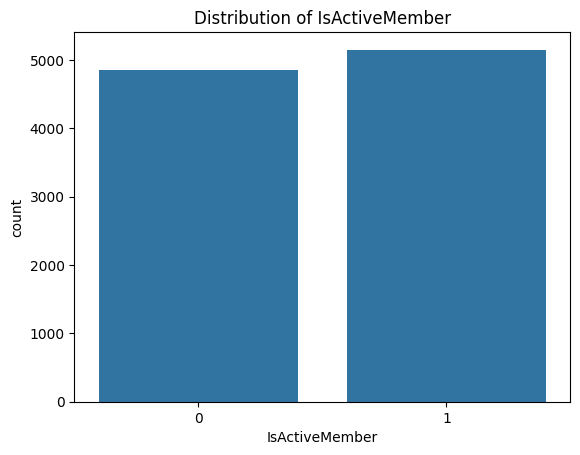

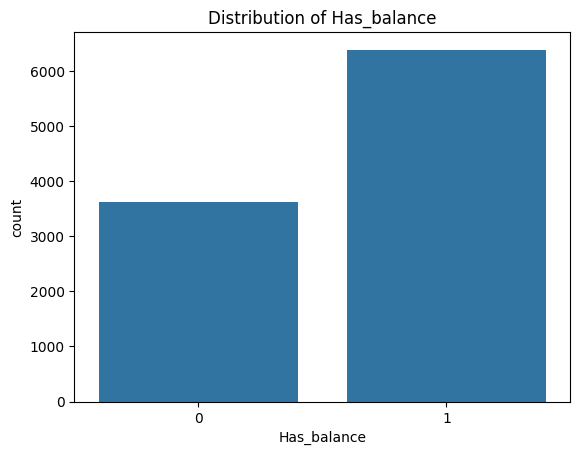

In [21]:
for col in binary_features:
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

In [22]:
churn_rate = df["Exited"].value_counts(normalize=True)
churn_rate

,proportion
Exited,
0,0.7963
1,0.2037


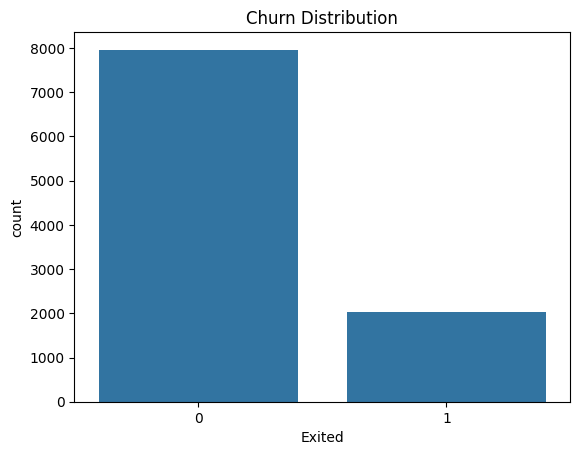

In [23]:
sns.countplot(x="Exited", data=df)
plt.title("Churn Distribution")
plt.show()

# Bivariate Analysis

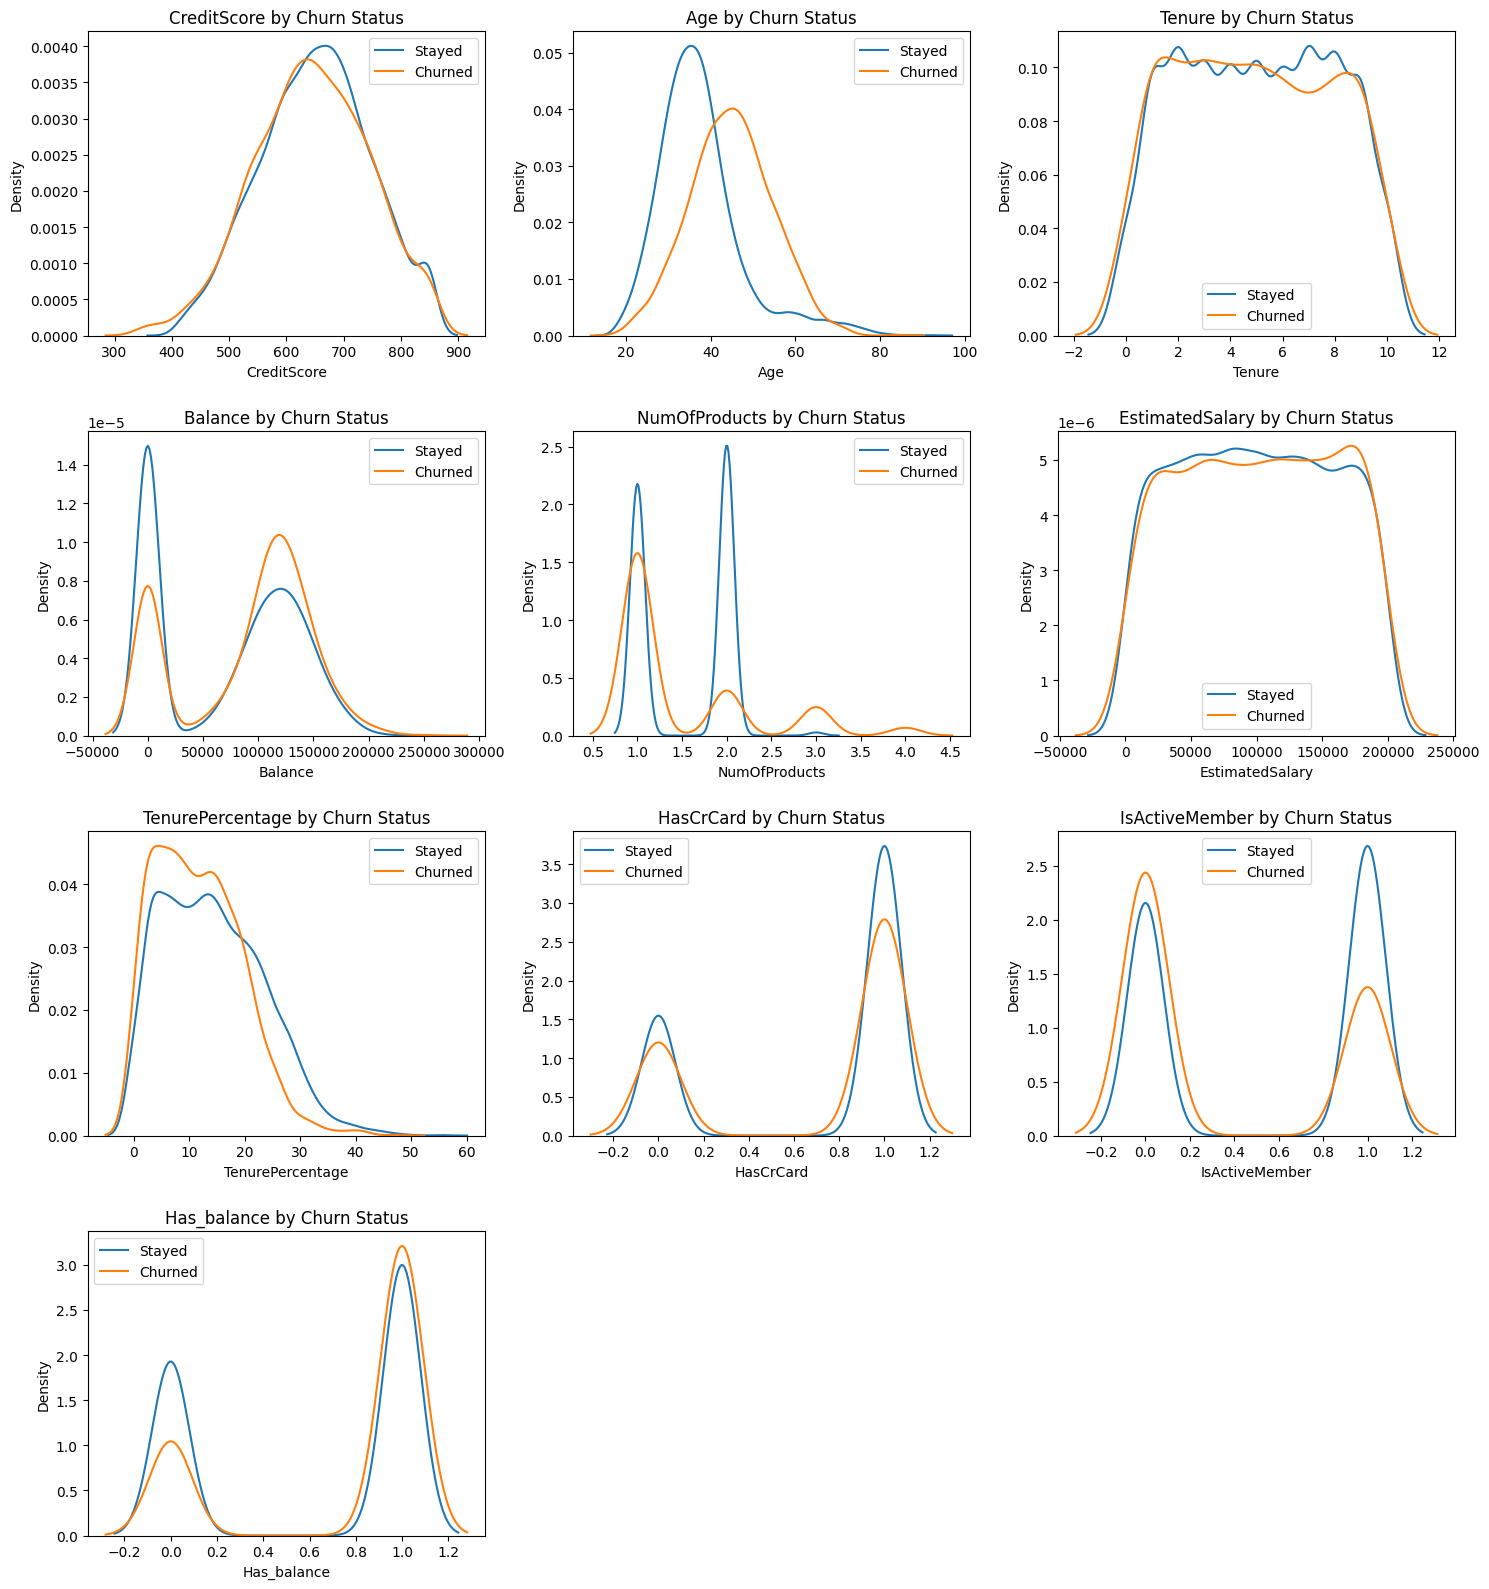

In [24]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

features = numerical_features + binary_features

# Number of columns in the grid
n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

# Create subplot matrix
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Plot KDE for each feature
for i, col in enumerate(features):
    sns.kdeplot(
        data=df[df["Exited"] == 0],
        x=col,
        label="Stayed",
        ax=axes[i]
    )

    sns.kdeplot(
        data=df[df["Exited"] == 1],
        x=col,
        label="Churned",
        ax=axes[i]
    )

    axes[i].set_title(f"{col} by Churn Status")
    axes[i].legend()

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

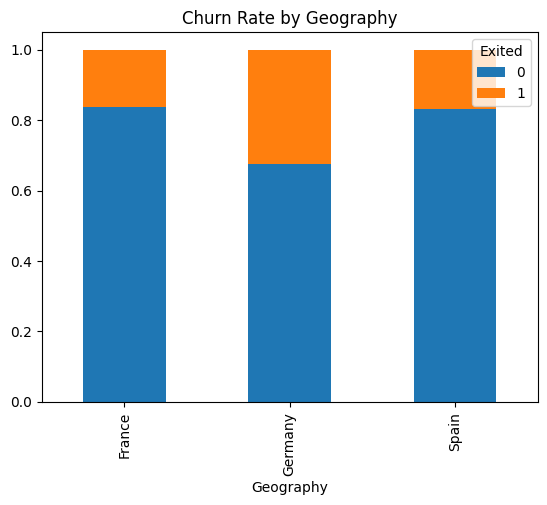

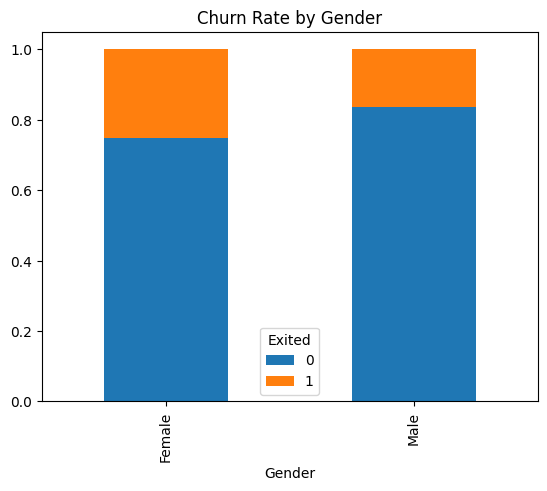

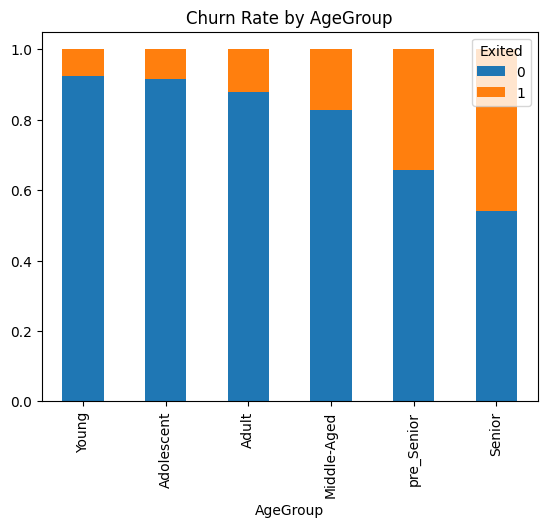

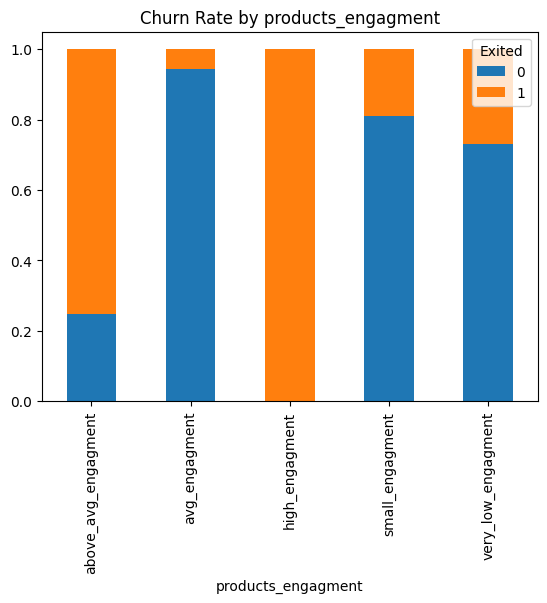

In [25]:
for col in categorical_features:
    churn_geo = pd.crosstab(df[col], df["Exited"], normalize="index")
    churn_geo.plot(kind="bar", stacked=True)
    plt.title(f"Churn Rate by {col}")
    plt.show()

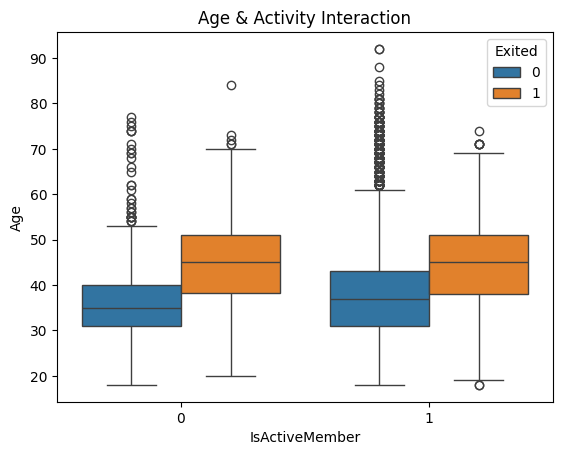

In [26]:
sns.boxplot(x="IsActiveMember", y="Age", hue="Exited", data=df)
plt.title("Age & Activity Interaction")
plt.show()

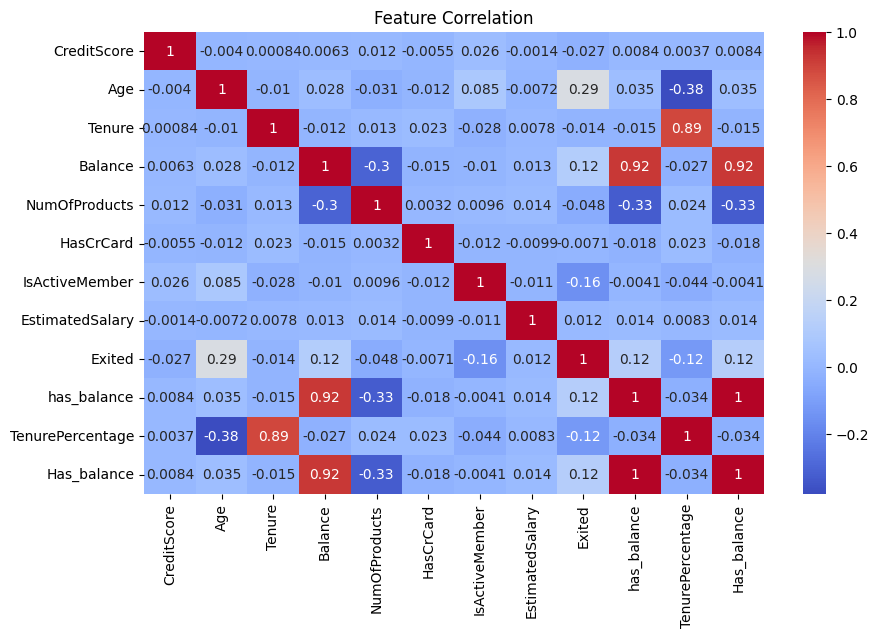

In [27]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True)
plt.title("Feature Correlation")
plt.show()

# Preprocessing

In [28]:
CATEGORICAL_FEATURES = ["Geography", "Gender","AgeGroup", "products_engagment"]

NUMERICAL_FEATURES_LINEAR = ["CreditScore","Tenure","NumOfProducts","EstimatedSalary"]

LOG_NUM_FEATURES = ["Balance","Age","TenurePercentage"]

BINARY_FEATURES = ["HasCrCard","IsActiveMember","Has_balance"]

In [29]:
for col in CATEGORICAL_FEATURES:
  df[col] = df[col].astype("category")

In [30]:
df.dtypes

,0
CreditScore,int64
Geography,category
Gender,category
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


In [31]:
X = df.drop('Exited',axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X,y,stratify=y,random_state=42)

In [36]:
log_pipeline = Pipeline(steps=[
    ('nan',SimpleImputer(strategy='mean')),
    ("log", FunctionTransformer(np.log1p, validate=True,feature_names_out='one-to-one')),
    ("scaler", StandardScaler())
])


numeric_pipeline_linear = Pipeline(steps=[
    ('nan',SimpleImputer(strategy='mean')),
    ("scaler", StandardScaler())
])

binary_pipeline = Pipeline(steps=[
    ('nan',SimpleImputer(strategy='most_frequent')),
    ("identity", FunctionTransformer(lambda x: x, validate=False,feature_names_out='one-to-one'))
])

categorical_pipeline = Pipeline(steps=[
    ('nan',SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False))
])


preprocessor = ColumnTransformer(
        transformers=[
            ("log_num", log_pipeline, LOG_NUM_FEATURES),
            ("num", numeric_pipeline_linear, NUMERICAL_FEATURES_LINEAR),
            ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
            ("bin", binary_pipeline, BINARY_FEATURES)
        ]
    )


preprocessor_cat = ColumnTransformer(
        transformers=[
            ("log_num", log_pipeline, LOG_NUM_FEATURES),
            ("num", numeric_pipeline_linear, NUMERICAL_FEATURES_LINEAR),
            ("cat", binary_pipeline, CATEGORICAL_FEATURES),
            ("bin", binary_pipeline, BINARY_FEATURES)
        ]
    )

In [37]:
X_train_processed = preprocessor.fit_transform(X_train)
X_train_df = pd.DataFrame(X_train_processed, columns=preprocessor.get_feature_names_out(),index=X_train.index)

X_test_processed = preprocessor.transform(X_test)
X_test_df = pd.DataFrame(X_test_processed, columns=preprocessor.get_feature_names_out(),index=X_test.index)

In [38]:
X_train_df.dtypes

,0
log_num__Balance,float64
log_num__Age,float64
log_num__TenurePercentage,float64
num__CreditScore,float64
num__Tenure,float64
num__NumOfProducts,float64
num__EstimatedSalary,float64
cat__Geography_Germany,float64
cat__Geography_Spain,float64
cat__Gender_Male,float64


In [39]:
X_cat_train_processed = preprocessor_cat.fit_transform(X_train)
X_cat_train_df = pd.DataFrame(X_cat_train_processed, columns=preprocessor_cat.get_feature_names_out(),index=X_train.index)


X_cat_test_processed = preprocessor_cat.transform(X_test)
X_cat_test_df = pd.DataFrame(X_cat_test_processed, columns=preprocessor_cat.get_feature_names_out(),index=X_test.index)

X_cat_train_df

,log_num__Balance,log_num__Age,log_num__TenurePercentage,num__CreditScore,num__Tenure,num__NumOfProducts,num__EstimatedSalary,cat__Geography,cat__Gender,cat__AgeGroup,cat__products_engagment,bin__HasCrCard,bin__IsActiveMember,bin__Has_balance
5866,0.765975,1.320314,0.412179,0.874378,1.028955,0.803861,1.237787,France,Female,Senior,avg_engagment,0,1,1
1938,0.710944,0.030137,-0.314113,-1.371272,-0.699103,-0.914771,1.095526,France,Male,Middle-Aged,small_engagment,0,1,1
4194,0.723113,1.393062,0.526341,-0.812446,1.374567,-0.914771,1.679687,Germany,Female,Senior,small_engagment,1,1,1
6332,0.709873,-0.287202,0.095616,-0.326061,-0.353492,-0.914771,-1.37866,France,Female,Adult,small_engagment,1,1,1
1,0.696347,0.323947,-1.477967,-0.439896,-1.390327,-0.914771,0.226947,Spain,Female,Middle-Aged,small_engagment,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3254,0.762089,1.093703,-0.299704,-1.019419,-0.353492,-0.914771,0.313566,Germany,Male,Senior,very_low_engagment,1,0,1
4644,-1.32495,2.622709,-0.481777,0.63636,-0.00788,0.803861,0.905641,Spain,Male,Senior,very_low_engagment,0,0,0
8942,0.668741,-0.072846,0.967359,0.170672,1.374567,0.803861,-0.555157,France,Female,Adult,avg_engagment,1,1,1
2935,0.729596,-0.287202,0.894264,0.377644,1.028955,0.803861,-1.349126,Spain,Male,Adult,very_low_engagment,1,0,1


In [40]:
X_cat_train_df.dtypes


,0
log_num__Balance,object
log_num__Age,object
log_num__TenurePercentage,object
num__CreditScore,object
num__Tenure,object
num__NumOfProducts,object
num__EstimatedSalary,object
cat__Geography,object
cat__Gender,object
cat__AgeGroup,object


In [41]:
for col in X_cat_train_df.columns:
    if col in ['cat__Geography', 'cat__Gender', 'cat__AgeGroup', 'cat__products_engagment']:
        X_cat_train_df[col] = X_cat_train_df[col].astype('category')
        X_cat_test_df[col] = X_cat_test_df[col].astype('category')
    else:
        X_cat_train_df[col] = X_cat_train_df[col].astype('float64')
        X_cat_test_df[col] = X_cat_test_df[col].astype('float64')

# Modeling

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix
)

Train Accuracy : 0.7436
Valid Accuracy : 0.7424
Precision: 0.4224865694551036
Recall   : 0.7205497382198953
F1       : 0.532656023222061
ROC-AUC  : 0.80840650785691


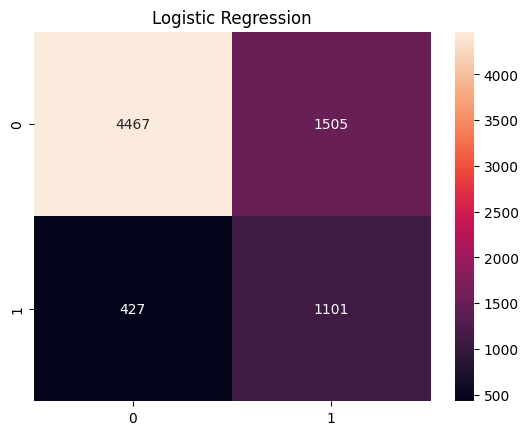

In [43]:
log_reg = LogisticRegression(random_state=42,class_weight='balanced')

log_reg.fit(X_train_df, y_train)

y_valid_pred = cross_val_predict(log_reg,X_train_df,y_train,cv=3,method='predict',n_jobs=-1)
y_valid_proba = cross_val_predict(log_reg,X_train_df,y_train,cv=3,method='predict_proba',n_jobs=-1)

print("Train Accuracy :", log_reg.score(X_train_df,y_train))
print("Valid Accuracy :", accuracy_score(y_train,y_valid_pred))
print("Precision:", precision_score(y_train,y_valid_pred))
print("Recall   :", recall_score(y_train,y_valid_pred))
print("F1       :", f1_score(y_train,y_valid_pred))
print("ROC-AUC  :", roc_auc_score(y_train,y_valid_proba[:,1]))

# confusion_matrix
cm = confusion_matrix(y_train,y_valid_pred)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("Logistic Regression")
plt.show()

Train Accuracy : 0.888
Valid Accuracy : 0.8545333333333334
Precision: 0.7094918504314478
Recall   : 0.48429319371727747
F1       : 0.5756514974718009
ROC-AUC  : 0.8472271779648832


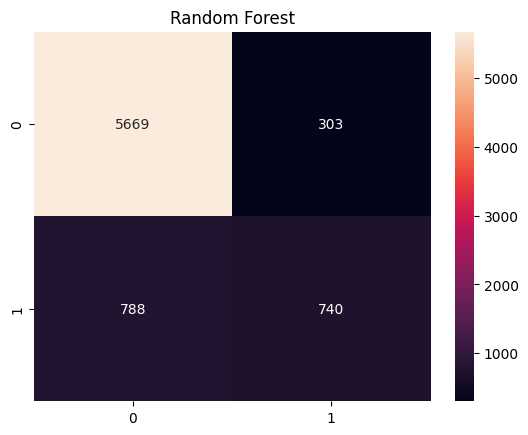

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=400,max_depth=11,max_samples=1500,random_state=42,class_weight='balanced',n_jobs=-1)

rf.fit(X_train_df, y_train)

y_valid_pred = cross_val_predict(rf,X_train_df,y_train,cv=3,method='predict',n_jobs=-1)
y_valid_proba = cross_val_predict(rf,X_train_df,y_train,cv=3,method='predict_proba',n_jobs=-1)

print("Train Accuracy :", rf.score(X_train_df,y_train))
print("Valid Accuracy :", accuracy_score(y_train,y_valid_pred))
print("Precision:", precision_score(y_train,y_valid_pred))
print("Recall   :", recall_score(y_train,y_valid_pred))
print("F1       :", f1_score(y_train,y_valid_pred))
print("ROC-AUC  :", roc_auc_score(y_train,y_valid_proba[:,1]))

# confusion_matrix
cm = confusion_matrix(y_train,y_valid_pred)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("Random Forest")
plt.show()

In [45]:
X_cat_train_df, X_cat_valid_df, y_train, y_valid = train_test_split(X_cat_train_df, y_train, test_size=0.2, stratify=y_train, random_state=42)

In [46]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)

3.909983633387889


# XGBoost

In [47]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,
    random_state=42,
    n_estimators=5000,
    early_stopping_rounds=30,
)

xgb.fit(
    X_cat_train_df,
    y_train,
    eval_set=[
        (X_cat_train_df, y_train),
        (X_cat_valid_df, y_valid)
    ],
    verbose=True
)

[0]	validation_0-logloss:0.58979	validation_1-logloss:0.59451
[1]	validation_0-logloss:0.53154	validation_1-logloss:0.54331
[2]	validation_0-logloss:0.49097	validation_1-logloss:0.50473
[3]	validation_0-logloss:0.46270	validation_1-logloss:0.48400
[4]	validation_0-logloss:0.44229	validation_1-logloss:0.46872
[5]	validation_0-logloss:0.42549	validation_1-logloss:0.45817
[6]	validation_0-logloss:0.41213	validation_1-logloss:0.44871
[7]	validation_0-logloss:0.39821	validation_1-logloss:0.44422
[8]	validation_0-logloss:0.38893	validation_1-logloss:0.44062
[9]	validation_0-logloss:0.38303	validation_1-logloss:0.43766
[10]	validation_0-logloss:0.37720	validation_1-logloss:0.43643
[11]	validation_0-logloss:0.37034	validation_1-logloss:0.43516
[12]	validation_0-logloss:0.36400	validation_1-logloss:0.43394
[13]	validation_0-logloss:0.36092	validation_1-logloss:0.43308
[14]	validation_0-logloss:0.35196	validation_1-logloss:0.43092
[15]	validation_0-logloss:0.34778	validation_1-logloss:0.43095
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=30,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=5000,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_valid_pred = xgb.predict(X_cat_valid_df)

print("Train Accuracy :", xgb.score(X_cat_train_df,y_train))
print("Valid Accuracy :", accuracy_score(y_valid,y_valid_pred))
print("Precision:", precision_score(y_valid,y_valid_pred))
print("Recall   :", recall_score(y_valid,y_valid_pred))
print("F1       :", f1_score(y_valid,y_valid_pred))
print("ROC-AUC  :", roc_auc_score(y_valid,xgb.predict_proba(X_cat_valid_df)[:,1]))

# confusion_matrix
cm = confusion_matrix(y_valid,y_valid_pred)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("XGBoost")
plt.show()

In [50]:
import optuna

def objective(trial):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_estimators": 5000,

        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 16),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma": trial.suggest_float("gamma", 0, 10),

        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.5, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-10, 20, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-10, 20, log=True),

        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            scale_pos_weight * 0.7,
            scale_pos_weight * 1.3,
        ),

        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),
        "max_bin": trial.suggest_int("max_bin", 128, 512),
    }

    model = XGBClassifier(
        **params,
        early_stopping_rounds=30,
        enable_categorical=True
    )

    model.fit(
        X_cat_train_df,
        y_train,
        eval_set=[
            (X_cat_valid_df, y_valid)
        ],
        verbose=False
    )


    return model.best_score

In [51]:
study = optuna.create_study(
    direction="minimize",
    study_name="XGBoost Churn"
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True
)

[I 2026-10-01 18:53:02,982] A new study created in memory with name: XGBoost Churn


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-10-01 18:53:06,842] Trial 0 finished with value: 0.43309017790729804 and parameters: {'learning_rate': 0.022475575271450336, 'max_depth': 16, 'min_child_weight': 1, 'gamma': 7.314710471325631, 'subsample': 0.7546678006917555, 'colsample_bytree': 0.522235404186999, 'colsample_bylevel': 0.9280508368534968, 'colsample_bynode': 0.8472365816390566, 'reg_alpha': 1.7138412222391952e-10, 'reg_lambda': 5.758136891286338e-05, 'scale_pos_weight': 3.984456957568014, 'max_delta_step': 7, 'max_bin': 130}. Best is trial 0 with value: 0.43309017790729804.
[I 2026-10-01 18:53:08,232] Trial 1 finished with value: 0.3979420829800268 and parameters: {'learning_rate': 0.12366382433100545, 'max_depth': 5, 'min_child_weight': 6, 'gamma': 1.3099298583439545, 'subsample': 0.5143516634448966, 'colsample_bytree': 0.7770231923011295, 'colsample_bylevel': 0.997288154021803, 'colsample_bynode': 0.5133880949410978, 'reg_alpha': 2.199673296465345, 'reg_lambda': 1.3122464340308024e-10, 'scale_pos_weight': 3.11

In [52]:
print(study.best_value)
study.best_params

0.33737488202999033


{'learning_rate': 0.01214994832632681,
 'max_depth': 12,
 'min_child_weight': 1,
 'gamma': 0.07245132071914079,
 'subsample': 0.6760124814612102,
 'colsample_bytree': 0.7418242492157113,
 'colsample_bylevel': 0.9855125939449814,
 'colsample_bynode': 0.8105114305416415,
 'reg_alpha': 0.47544009850864277,
 'reg_lambda': 0.00032251499342045417,
 'scale_pos_weight': 2.890865615819197,
 'max_delta_step': 0,
 'max_bin': 409}

In [53]:
best_model = XGBClassifier(
    **study.best_params,
    objective="binary:logistic",
    tree_method="hist",
    eval_metric="logloss",
    random_state=42,
    n_estimators=5000,
    early_stopping_rounds=30,
    enable_categorical=True
)

best_model.fit(
    X_cat_train_df,
    y_train,
    eval_set=[
        (X_cat_train_df, y_train),
        (X_cat_valid_df, y_valid)
    ],
    verbose=True
)

[0]	validation_0-logloss:0.60964	validation_1-logloss:0.61101
[1]	validation_0-logloss:0.60439	validation_1-logloss:0.60721
[2]	validation_0-logloss:0.59896	validation_1-logloss:0.60333
[3]	validation_0-logloss:0.59353	validation_1-logloss:0.59994
[4]	validation_0-logloss:0.58831	validation_1-logloss:0.59678
[5]	validation_0-logloss:0.58350	validation_1-logloss:0.59329
[6]	validation_0-logloss:0.57816	validation_1-logloss:0.58906
[7]	validation_0-logloss:0.57321	validation_1-logloss:0.58526
[8]	validation_0-logloss:0.56841	validation_1-logloss:0.58128
[9]	validation_0-logloss:0.56336	validation_1-logloss:0.57772
[10]	validation_0-logloss:0.55804	validation_1-logloss:0.57379
[11]	validation_0-logloss:0.55341	validation_1-logloss:0.57042
[12]	validation_0-logloss:0.54845	validation_1-logloss:0.56675
[13]	validation_0-logloss:0.54413	validation_1-logloss:0.56346
[14]	validation_0-logloss:0.53914	validation_1-logloss:0.55949
[15]	validation_0-logloss:0.53473	validation_1-logloss:0.55609
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.9855125939449814,
              colsample_bynode=0.8105114305416415,
              colsample_bytree=0.7418242492157113, device=None,
              early_stopping_rounds=30, enable_categorical=True,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.07245132071914079, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01214994832632681,
              max_bin=409, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=0, max_depth=12, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=5000, n_jobs=None,
              num_parallel_tree=None, ...)

Train Accuracy : 0.9928333333333333
Valid Accuracy : 0.862
Precision: 0.6896551724137931
Recall   : 0.5882352941176471
F1       : 0.6349206349206349
ROC-AUC  : 0.867173558423928


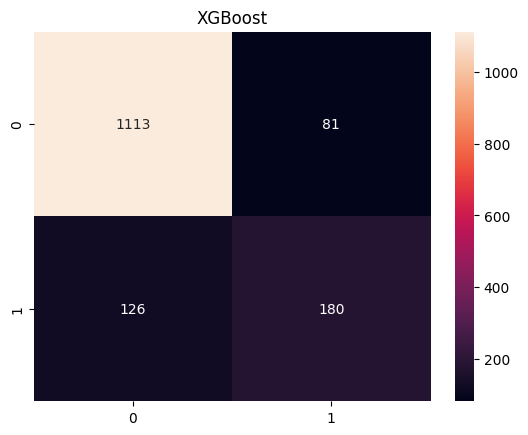

In [54]:
y_valid_pred = best_model.predict(X_cat_valid_df)

print("Train Accuracy :", best_model.score(X_cat_train_df,y_train))
print("Valid Accuracy :", accuracy_score(y_valid,y_valid_pred))
print("Precision:", precision_score(y_valid,y_valid_pred))
print("Recall   :", recall_score(y_valid,y_valid_pred))
print("F1       :", f1_score(y_valid,y_valid_pred))
print("ROC-AUC  :", roc_auc_score(y_valid,best_model.predict_proba(X_cat_valid_df)[:,1]))

# confusion_matrix
cm = confusion_matrix(y_valid,y_valid_pred)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("XGBoost")
plt.show()

# XGB Overfitting

In [55]:
import optuna

def objective(trial):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_estimators": 5000,

        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 16),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma": trial.suggest_float("gamma", 0, 10),

        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.5, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-10, 20, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-10, 20, log=True),

        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            scale_pos_weight * 0.7,
            scale_pos_weight * 1.3,
        ),

        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),
        "max_bin": trial.suggest_int("max_bin", 128, 512),
    }

    model = XGBClassifier(
        **params,
        early_stopping_rounds=30,
        enable_categorical=True
    )

    model.fit(
        X_cat_train_df,
        y_train,
        eval_set=[
            (X_cat_valid_df, y_valid)
        ],
        verbose=False
    )

    # Predictions
    train_pred = model.predict_proba(X_cat_train_df, iteration_range=(0, model.best_iteration + 1))[:, 1]
    valid_pred = model.predict_proba(X_cat_valid_df, iteration_range=(0, model.best_iteration + 1))[:, 1]

    train_loss = log_loss(
        y_train,
        train_pred,
    )

    valid_loss = log_loss(
        y_valid,
        valid_pred,
    )

    # Relative overfitting gap
    penalty = max(0, valid_loss - train_loss)
    score = valid_loss + 0.4 * penalty

    return score

In [56]:
study = optuna.create_study(
    direction="minimize",
    study_name="XGBoost Churn"
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True
)

[I 2026-10-01 19:03:33,316] A new study created in memory with name: XGBoost Churn


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-10-01 19:04:30,564] Trial 0 finished with value: 0.5572331241053037 and parameters: {'learning_rate': 0.00011813140805016153, 'max_depth': 13, 'min_child_weight': 3, 'gamma': 5.015324995748523, 'subsample': 0.7585620812400471, 'colsample_bytree': 0.8730592320605481, 'colsample_bylevel': 0.5531197487673855, 'colsample_bynode': 0.7962750447030975, 'reg_alpha': 2.0402246453057584e-07, 'reg_lambda': 0.020754193177400918, 'scale_pos_weight': 3.9352810408451377, 'max_delta_step': 7, 'max_bin': 357}. Best is trial 0 with value: 0.5572331241053037.
[I 2026-10-01 19:05:42,876] Trial 1 finished with value: 0.5340467382006616 and parameters: {'learning_rate': 0.00036515383869486015, 'max_depth': 14, 'min_child_weight': 18, 'gamma': 0.7017128016509677, 'subsample': 0.7362966884087989, 'colsample_bytree': 0.6364752873905617, 'colsample_bylevel': 0.6842024009805462, 'colsample_bynode': 0.8449650566888609, 'reg_alpha': 0.305025868044979, 'reg_lambda': 1.4418625619390502e-09, 'scale_pos_weight

In [58]:
print(study.best_value)
study.best_params

0.40401273800632104


{'learning_rate': 0.00143050345527033,
 'max_depth': 8,
 'min_child_weight': 7,
 'gamma': 2.2370681255003695,
 'subsample': 0.9085201277689614,
 'colsample_bytree': 0.7170338515306789,
 'colsample_bylevel': 0.8739909577050857,
 'colsample_bynode': 0.5340005557905815,
 'reg_alpha': 0.005993443199029717,
 'reg_lambda': 4.637757500894158,
 'scale_pos_weight': 2.7526146993064446,
 'max_delta_step': 5,
 'max_bin': 340}

In [59]:
best_model = XGBClassifier(
    **study.best_params,
    objective="binary:logistic",
    tree_method="hist",
    eval_metric="logloss",
    random_state=42,
    n_estimators=5000,
    early_stopping_rounds=30,
    enable_categorical=True
)

best_model.fit(
    X_cat_train_df,
    y_train,
    eval_set=[
        (X_cat_train_df, y_train),
        (X_cat_valid_df, y_valid)
    ],
    verbose=True
)

[0]	validation_0-logloss:0.60478	validation_1-logloss:0.60491
[1]	validation_0-logloss:0.60444	validation_1-logloss:0.60457
[2]	validation_0-logloss:0.60404	validation_1-logloss:0.60419
[3]	validation_0-logloss:0.60372	validation_1-logloss:0.60389
[4]	validation_0-logloss:0.60345	validation_1-logloss:0.60363
[5]	validation_0-logloss:0.60309	validation_1-logloss:0.60330
[6]	validation_0-logloss:0.60275	validation_1-logloss:0.60300
[7]	validation_0-logloss:0.60240	validation_1-logloss:0.60269
[8]	validation_0-logloss:0.60216	validation_1-logloss:0.60247
[9]	validation_0-logloss:0.60177	validation_1-logloss:0.60210
[10]	validation_0-logloss:0.60142	validation_1-logloss:0.60179
[11]	validation_0-logloss:0.60100	validation_1-logloss:0.60139
[12]	validation_0-logloss:0.60063	validation_1-logloss:0.60105
[13]	validation_0-logloss:0.60022	validation_1-logloss:0.60066
[14]	validation_0-logloss:0.59982	validation_1-logloss:0.60028
[15]	validation_0-logloss:0.59950	validation_1-logloss:0.60000
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.8739909577050857,
              colsample_bynode=0.5340005557905815,
              colsample_bytree=0.7170338515306789, device=None,
              early_stopping_rounds=30, enable_categorical=True,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=2.2370681255003695, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.00143050345527033,
              max_bin=340, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=5, max_depth=8, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=5000, n_jobs=None,
              num_parallel_tree=None, ...)

Train Accuracy : 0.8781666666666667
Valid Accuracy : 0.852
Precision: 0.622093023255814
Recall   : 0.6993464052287581
F1       : 0.6584615384615384
ROC-AUC  : 0.8693522076614006


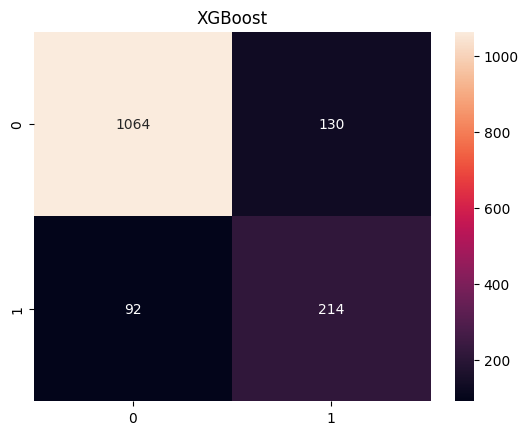

In [60]:
y_valid_pred = best_model.predict(X_cat_valid_df)

print("Train Accuracy :", best_model.score(X_cat_train_df,y_train))
print("Valid Accuracy :", accuracy_score(y_valid,y_valid_pred))
print("Precision:", precision_score(y_valid,y_valid_pred))
print("Recall   :", recall_score(y_valid,y_valid_pred))
print("F1       :", f1_score(y_valid,y_valid_pred))
print("ROC-AUC  :", roc_auc_score(y_valid,best_model.predict_proba(X_cat_valid_df)[:,1]))

# confusion_matrix
cm = confusion_matrix(y_valid,y_valid_pred)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("XGBoost")
plt.show()

# LightGBM

In [61]:
from lightgbm import LGBMClassifier
import lightgbm as lgb

gbm = LGBMClassifier(
    objective="binary",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=5000,
)

gbm.fit(
    X_cat_train_df,
    y_train,
    eval_set=[
        (X_cat_train_df, y_train),
        (X_cat_valid_df, y_valid)
        ],
    callbacks=[
        lgb.early_stopping(30, verbose=True)
    ]
)

[LightGBM] [Info] Number of positive: 1222, number of negative: 4778
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000310 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1127
[LightGBM] [Info] Number of data points in the train set: 6000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203667 -> initscore=-1.363533
[LightGBM] [Info] Start training from score -1.363533
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[11]	training's binary_logloss: 0.394635	valid_1's binary_logloss: 0.41708


LGBMClassifier(n_estimators=5000, objective='binary', random_state=42,
               scale_pos_weight=np.float64(3.909983633387889))

In [62]:
def objective(trial):

    params = {
        "objective": "binary",
        "metric": "binary_logloss",
        "boosting_type": "gbdt",
        "random_state": 42,
        "n_estimators": 5000,
        "verbosity": -1,

        # Tree complexity
        "num_leaves": trial.suggest_int(
            "num_leaves",
            16,
            512,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            -1,
            16
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            200
        ),

        "min_split_gain": trial.suggest_float(
            "min_split_gain",
            0.0,
            1.0
        ),

        # Learning
        "learning_rate": trial.suggest_float(
            "learning_rate",
            1e-3,
            0.2,
            log=True
        ),

        # Row Sampling
        "bagging_fraction": trial.suggest_float(
            "bagging_fraction",
            0.5,
            1.0
        ),

        "bagging_freq": trial.suggest_int(
            "bagging_freq",
            1,
            10
        ),

        # Column Sampling
        "feature_fraction": trial.suggest_float(
            "feature_fraction",
            0.5,
            1.0
        ),

        # Regularization
        "lambda_l1": trial.suggest_float(
            "lambda_l1",
            1e-8,
            20,
            log=True
        ),

        "lambda_l2": trial.suggest_float(
            "lambda_l2",
            1e-8,
            20,
            log=True
        ),

        # Handling imbalance
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            scale_pos_weight * 0.7,
            scale_pos_weight * 1.3
        ),

        # Histogram
        "max_bin": trial.suggest_int(
            "max_bin",
            127,
            511
        ),
    }

    model = LGBMClassifier(**params)

    model.fit(
        X_cat_train_df,
        y_train,
        eval_set=[(X_cat_valid_df, y_valid)],
        callbacks=[
            lgb.early_stopping(30, verbose=False)
        ]
    )

    return model.best_score_['valid_0']['binary_logloss']

In [63]:
study = optuna.create_study(
    direction="minimize",
    study_name="LGBM Churn"
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True
)

[I 2026-10-01 19:27:15,234] A new study created in memory with name: LGBM Churn


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-10-01 19:27:15,999] Trial 0 finished with value: 0.35323113066597284 and parameters: {'num_leaves': 250, 'max_depth': 13, 'min_child_samples': 19, 'min_split_gain': 0.7285522899031434, 'learning_rate': 0.042328906500111896, 'bagging_fraction': 0.6797722233629762, 'bagging_freq': 7, 'feature_fraction': 0.9404665237234213, 'lambda_l1': 9.208241979922408e-06, 'lambda_l2': 4.1230534018092184e-07, 'scale_pos_weight': 3.3285780299638277, 'max_bin': 201}. Best is trial 0 with value: 0.35323113066597284.
[I 2026-10-01 19:27:16,195] Trial 1 finished with value: 0.4384318510310834 and parameters: {'num_leaves': 102, 'max_depth': 14, 'min_child_samples': 87, 'min_split_gain': 0.9996819833482892, 'learning_rate': 0.021286640309830362, 'bagging_fraction': 0.9292596552201449, 'bagging_freq': 6, 'feature_fraction': 0.5665618702995511, 'lambda_l1': 4.632231475302919e-06, 'lambda_l2': 6.223290626854866e-07, 'scale_pos_weight': 4.4111608845557555, 'max_bin': 129}. Best is trial 0 with value: 0.3

In [64]:
print(study.best_value)
study.best_params

0.3376052931295167


{'num_leaves': 186,
 'max_depth': 15,
 'min_child_samples': 7,
 'min_split_gain': 0.6751972685579659,
 'learning_rate': 0.011147410551673053,
 'bagging_fraction': 0.7199269636638759,
 'bagging_freq': 1,
 'feature_fraction': 0.889142566789518,
 'lambda_l1': 0.000354485718593944,
 'lambda_l2': 6.409079782817938e-08,
 'scale_pos_weight': 2.906356228888568,
 'max_bin': 216}

In [65]:
best_model = LGBMClassifier(
    **study.best_params,
    objective= "binary",
    metric= "binary_logloss",
    boosting_type= "gbdt",
    random_state= 42,
    n_estimators= 5000,
    verbosity= -1,
)

best_model.fit(
    X_cat_train_df,
    y_train,
    eval_set=[
        (X_cat_train_df, y_train),
        (X_cat_valid_df, y_valid)
        ],
    callbacks=[
        lgb.early_stopping(30, verbose=True)
    ]
)

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[264]	training's binary_logloss: 0.152082	valid_1's binary_logloss: 0.337605


LGBMClassifier(bagging_fraction=0.7199269636638759, bagging_freq=1,
               feature_fraction=0.889142566789518,
               lambda_l1=0.000354485718593944, lambda_l2=6.409079782817938e-08,
               learning_rate=0.011147410551673053, max_bin=216, max_depth=15,
               metric='binary_logloss', min_child_samples=7,
               min_split_gain=0.6751972685579659, n_estimators=5000,
               num_leaves=186, objective='binary', random_state=42,
               scale_pos_weight=2.906356228888568, verbosity=-1)

Train Accuracy : 0.9815
Valid Accuracy : 0.8653333333333333
Precision: 0.6954887218045113
Recall   : 0.6045751633986928
F1       : 0.6468531468531469
ROC-AUC  : 0.8653698777109949


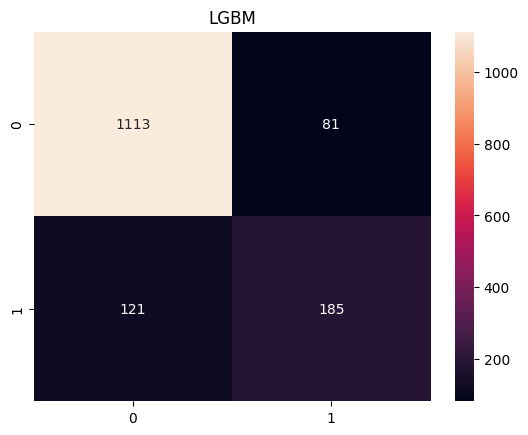

In [66]:
y_valid_pred = best_model.predict(X_cat_valid_df)

print("Train Accuracy :", best_model.score(X_cat_train_df,y_train))
print("Valid Accuracy :", accuracy_score(y_valid,y_valid_pred))
print("Precision:", precision_score(y_valid,y_valid_pred))
print("Recall   :", recall_score(y_valid,y_valid_pred))
print("F1       :", f1_score(y_valid,y_valid_pred))
print("ROC-AUC  :", roc_auc_score(y_valid,best_model.predict_proba(X_cat_valid_df)[:,1]))

# confusion_matrix
cm = confusion_matrix(y_valid,y_valid_pred)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("LGBM")
plt.show()

In [67]:
def objective(trial):

    params = {
        "objective": "binary",
        "metric": "binary_logloss",
        "boosting_type": "gbdt",
        "random_state": 42,
        "n_estimators": 5000,
        "verbosity": -1,

        # Tree complexity
        "num_leaves": trial.suggest_int(
            "num_leaves",
            16,
            512,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            -1,
            16
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            200
        ),

        "min_split_gain": trial.suggest_float(
            "min_split_gain",
            0.0,
            1.0
        ),

        # Learning
        "learning_rate": trial.suggest_float(
            "learning_rate",
            1e-3,
            0.2,
            log=True
        ),

        # Row Sampling
        "bagging_fraction": trial.suggest_float(
            "bagging_fraction",
            0.5,
            1.0
        ),

        "bagging_freq": trial.suggest_int(
            "bagging_freq",
            1,
            10
        ),

        # Column Sampling
        "feature_fraction": trial.suggest_float(
            "feature_fraction",
            0.5,
            1.0
        ),

        # Regularization
        "lambda_l1": trial.suggest_float(
            "lambda_l1",
            1e-8,
            20,
            log=True
        ),

        "lambda_l2": trial.suggest_float(
            "lambda_l2",
            1e-8,
            20,
            log=True
        ),

        # Handling imbalance
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            scale_pos_weight * 0.7,
            scale_pos_weight * 1.3
        ),

        # Histogram
        "max_bin": trial.suggest_int(
            "max_bin",
            127,
            511
        ),
    }

    model = LGBMClassifier(**params)

    model.fit(
        X_cat_train_df,
        y_train,
        eval_set=[(X_cat_valid_df, y_valid)],
        callbacks=[
            lgb.early_stopping(30, verbose=False)
        ]
    )

    # Predictions
    train_pred = model.predict_proba(X_cat_train_df)[:, 1]
    valid_pred = model.predict_proba(X_cat_valid_df)[:, 1]

    train_loss = log_loss(
        y_train,
        train_pred,
    )

    valid_loss = log_loss(
        y_valid,
        valid_pred,
    )

    # Relative overfitting gap
    penalty = max(0, valid_loss - train_loss)
    score = valid_loss + 0.4 * penalty

    return score

In [68]:
study = optuna.create_study(
    direction="minimize",
    study_name="LGBM Churn"
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True
)

[I 2026-10-01 19:29:13,144] A new study created in memory with name: LGBM Churn


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-10-01 19:29:13,636] Trial 0 finished with value: 0.4416071343679655 and parameters: {'num_leaves': 65, 'max_depth': 13, 'min_child_samples': 126, 'min_split_gain': 0.33304918810720996, 'learning_rate': 0.005332976829789424, 'bagging_fraction': 0.6996540311558879, 'bagging_freq': 3, 'feature_fraction': 0.9069808773154, 'lambda_l1': 0.00035712367755782716, 'lambda_l2': 3.0123486865505314e-08, 'scale_pos_weight': 4.634762171150641, 'max_bin': 160}. Best is trial 0 with value: 0.4416071343679655.
[I 2026-10-01 19:29:13,884] Trial 1 finished with value: 0.4647825961749446 and parameters: {'num_leaves': 144, 'max_depth': 16, 'min_child_samples': 34, 'min_split_gain': 0.7658790635394559, 'learning_rate': 0.17237969926634825, 'bagging_fraction': 0.5094825144983419, 'bagging_freq': 1, 'feature_fraction': 0.9140092737011216, 'lambda_l1': 0.3387716524674639, 'lambda_l2': 0.09580075681217241, 'scale_pos_weight': 4.124549255370649, 'max_bin': 262}. Best is trial 0 with value: 0.441607134367

In [69]:
best_model = LGBMClassifier(
    **study.best_params,
    objective= "binary",
    metric= "binary_logloss",
    boosting_type= "gbdt",
    random_state= 42,
    n_estimators= 5000,
    verbosity= -1,
)

best_model.fit(
    X_cat_train_df,
    y_train,
    eval_set=[
        (X_cat_train_df, y_train),
        (X_cat_valid_df, y_valid)
        ],
    callbacks=[
        lgb.early_stopping(30, verbose=True)
    ]
)

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[2271]	training's binary_logloss: 0.288461	valid_1's binary_logloss: 0.365506


LGBMClassifier(bagging_fraction=0.5283599957893226, bagging_freq=6,
               feature_fraction=0.6881161249008468,
               lambda_l1=3.7891799775868846e-07,
               lambda_l2=0.0001068978770476545,
               learning_rate=0.0013735789515640093, max_bin=423, max_depth=9,
               metric='binary_logloss', min_child_samples=23,
               min_split_gain=0.10948605310959413, n_estimators=5000,
               num_leaves=122, objective='binary', random_state=42,
               scale_pos_weight=2.788391595943432, verbosity=-1)

Train Accuracy : 0.9006666666666666
Valid Accuracy : 0.8586666666666667
Precision: 0.6496815286624203
Recall   : 0.6666666666666666
F1       : 0.6580645161290323
ROC-AUC  : 0.867846859570182


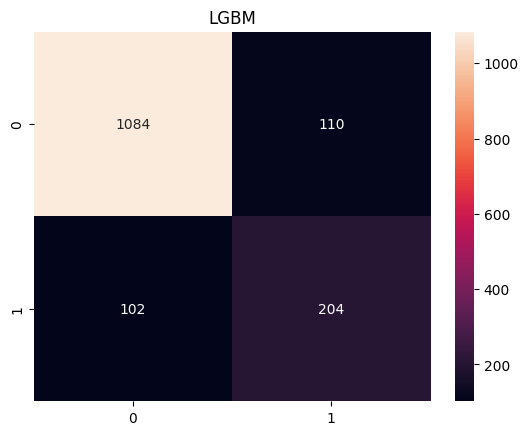

In [70]:
y_valid_pred = best_model.predict(X_cat_valid_df)

print("Train Accuracy :", best_model.score(X_cat_train_df,y_train))
print("Valid Accuracy :", accuracy_score(y_valid,y_valid_pred))
print("Precision:", precision_score(y_valid,y_valid_pred))
print("Recall   :", recall_score(y_valid,y_valid_pred))
print("F1       :", f1_score(y_valid,y_valid_pred))
print("ROC-AUC  :", roc_auc_score(y_valid,best_model.predict_proba(X_cat_valid_df)[:,1]))

# confusion_matrix
cm = confusion_matrix(y_valid,y_valid_pred)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("LGBM")
plt.show()

In [ ]:
import shap

explainer = shap.Explainer(best_model)
shap_values = explainer(X_cat_valid_df)

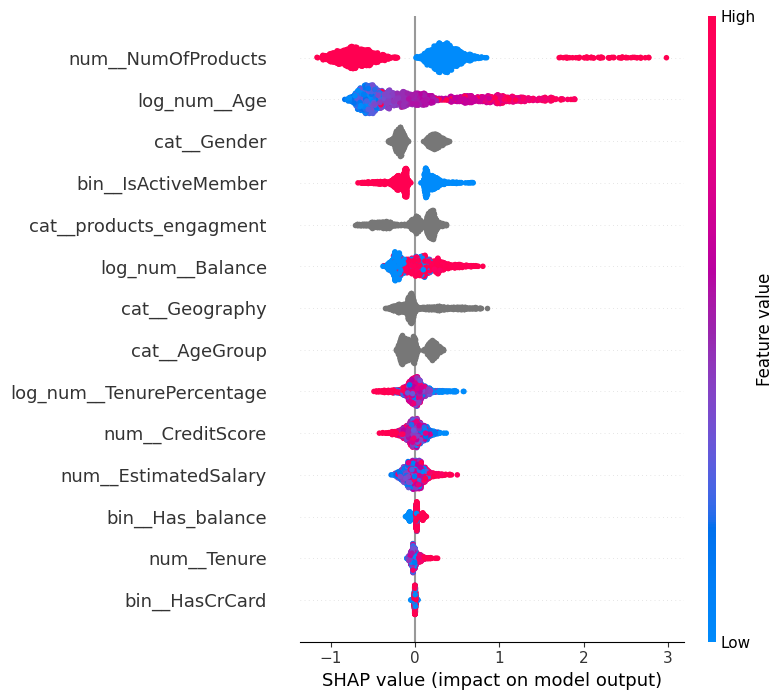

In [76]:
shap.summary_plot(shap_values, X_cat_valid_df)

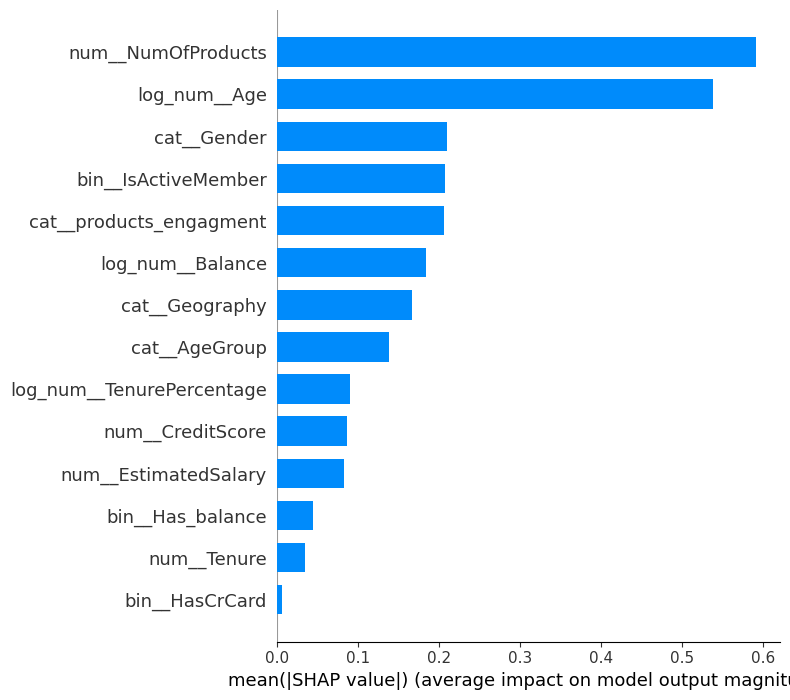

In [77]:
shap.summary_plot(shap_values, X_cat_valid_df, plot_type="bar")

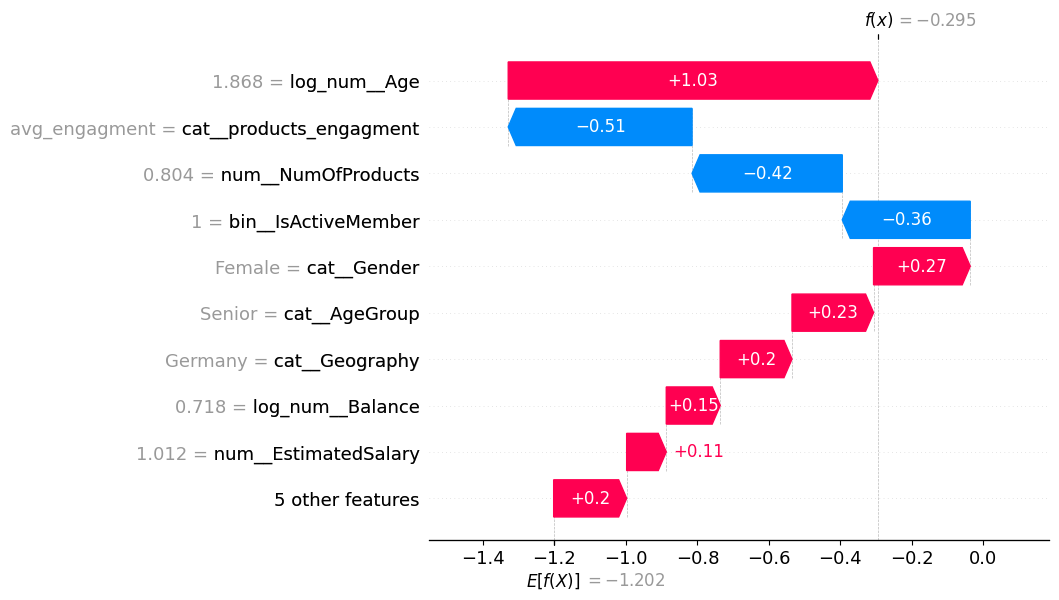

In [78]:
shap.plots.waterfall(shap_values[100])

Test Accuracy : 0.8528
Precision: 0.6353166986564299
Recall   : 0.650294695481336
F1       : 0.6427184466019418
ROC-AUC  : 0.8700024372939524


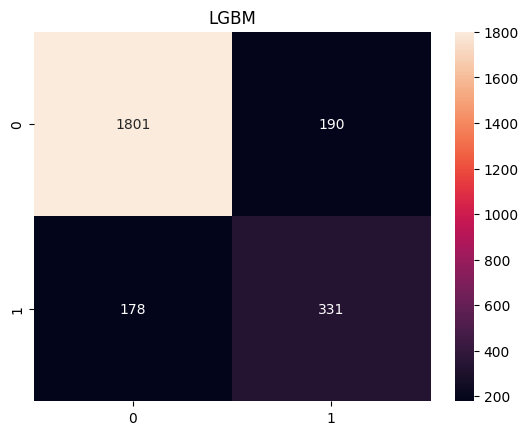

In [79]:
# test set evaluation

test_predictions = best_model.predict(X_cat_test_df)

print("Test Accuracy :", accuracy_score(y_test,test_predictions))
print("Precision:", precision_score(y_test,test_predictions))
print("Recall   :", recall_score(y_test,test_predictions))
print("F1       :", f1_score(y_test,test_predictions))
print("ROC-AUC  :", roc_auc_score(y_test,best_model.predict_proba(X_cat_test_df)[:,1]))

# confusion_matrix
cm = confusion_matrix(y_test,test_predictions)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("LGBM")
plt.show()